# BMM OR MATMUL
BMM, bsx197x1024, bsx1024x197 => MM, bs*197x1024, 1024xbs*197

In [1]:
import numpy as np
import torch
import torch.utils.benchmark as benchmark
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import wraps
from time import perf_counter
from collections import namedtuple

from ragdoll.utils import *
from ragdoll.visualisation import *
from ragdoll.benchmark import *
import ragdoll

2024-03-29 16:24:24.936850: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [2]:

bmm_results = []
bmm_throughput = []
for size in list(range(16, 1500, 16)):
    B = 4
    M = size // B
    N = size // B
    K = size
    print("benchmarking {}x{}x{}x{}".format(B, M, K, N))
    BENCH_CNT=33
    mm_src = f"""module BRKLEFT
      func.func @matmul(%arg0: tensor<{B}x{M}x{K}xf32>, %arg1: tensor<{B}x{K}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32> BRKLEFT
        %cst = arith.constant 0.000000e+00 : f32
        %0 = tensor.empty() : tensor<{B}x{M}x{N}xf32>
        %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<{B}x{M}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32>
        %2 = linalg.batch_matmul ins(%arg0, %arg1 : tensor<{B}x{M}x{K}xf32>, tensor<{B}x{K}x{N}xf32>) outs(%1 : tensor<{B}x{M}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32>
        return %2 : tensor<{B}x{M}x{N}xf32>
      BRKRIGHT
    BRKRIGHT"""

    mm_src = mm_src.replace("BRKLEFT", "{")
    mm_src = mm_src.replace("BRKRIGHT", "}")
    
    mlir_file_name = "mm_src.mlir"
    with open(mlir_file_name, "w", encoding="utf-8") as mlir_file:
        mlir_file.write(mm_src)
    #"""
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-hal-cuda-llvm-target-arch=sm_86
    """
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=llvm-cpu \
    --iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
    --iree-opt-const-eval=1 \
    --iree-opt-const-expr-hoisting=1 \
    --iree-opt-numeric-precision-reduction=1 \
    --iree-llvmcpu-target-cpu-features=host \
    --iree-llvmcpu-enable-ukernels=all \
    --iree-llvmcpu-slp-vectorization=1 \
    --iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    #print(tf_bench)
    
    
    ragdoll_bench = ragdoll_op_benchmark(
        mlir_file_name + ".vmfb",
        [(B, M, K), (B, K, N)],
        device='gpu',
        warmups=3,
        repetitions=BENCH_CNT, 
        measure_count=1)
    #print(np.mean(ragdoll_bench))
    bmm_results.append(np.mean(ragdoll_bench))
    GFLOPS = 2*B*M*K*N*1000000000
    bmm_throughput.append(GFLOPS/np.mean(ragdoll_bench))
bmm_data = pd.DataFrame([list(range(16, 1500, 16)), bmm_results])
bmm_data.to_csv('op_spec_bmm_gpu.csv')

benchmarking 4x4x16x4


/root/AlbertResearches/researches/Ragdoll/ragdoll/benchmark/op_benchmark.py:185: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


benchmarking 4x8x32x8
benchmarking 4x12x48x12
benchmarking 4x16x64x16
benchmarking 4x20x80x20
benchmarking 4x24x96x24
benchmarking 4x28x112x28
benchmarking 4x32x128x32
benchmarking 4x36x144x36
benchmarking 4x40x160x40
benchmarking 4x44x176x44
benchmarking 4x48x192x48
benchmarking 4x52x208x52
benchmarking 4x56x224x56
benchmarking 4x60x240x60
benchmarking 4x64x256x64
benchmarking 4x68x272x68
benchmarking 4x72x288x72
benchmarking 4x76x304x76
benchmarking 4x80x320x80
benchmarking 4x84x336x84
benchmarking 4x88x352x88
benchmarking 4x92x368x92
benchmarking 4x96x384x96
benchmarking 4x100x400x100
benchmarking 4x104x416x104
benchmarking 4x108x432x108
benchmarking 4x112x448x112
benchmarking 4x116x464x116
benchmarking 4x120x480x120
benchmarking 4x124x496x124
benchmarking 4x128x512x128
benchmarking 4x132x528x132
benchmarking 4x136x544x136
benchmarking 4x140x560x140
benchmarking 4x144x576x144
benchmarking 4x148x592x148
benchmarking 4x152x608x152
benchmarking 4x156x624x156
benchmarking 4x160x640x160


In [3]:

mm_results = []
mm_throughput = []
for size in list(range(16, 1500, 16)):
    M = size
    N = size
    K = size
    print("benchmarking {}x{}x{}".format(size, size, size))
    BENCH_CNT=33
    mm_src = f"""module BRKLEFT
      func.func @matmul(%arg0: tensor<{M}x{K}xf32>, %arg1: tensor<{K}x{N}xf32>) -> tensor<{M}x{N}xf32> BRKLEFT
        %cst = arith.constant 0.000000e+00 : f32
        %0 = tensor.empty() : tensor<{M}x{N}xf32>
        %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<{M}x{N}xf32>) -> tensor<{M}x{N}xf32>
        %2 = linalg.matmul ins(%arg0, %arg1 : tensor<{M}x{K}xf32>, tensor<{K}x{N}xf32>) outs(%1 : tensor<{M}x{N}xf32>) -> tensor<{M}x{N}xf32>
        return %2 : tensor<{M}x{N}xf32>
      BRKRIGHT
    BRKRIGHT"""

    mm_src = mm_src.replace("BRKLEFT", "{")
    mm_src = mm_src.replace("BRKRIGHT", "}")
    
    mlir_file_name = "mm_src.mlir"
    with open(mlir_file_name, "w", encoding="utf-8") as mlir_file:
        mlir_file.write(mm_src)
    #"""
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-hal-cuda-llvm-target-arch=sm_86
    """
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=llvm-cpu \
    --iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
    --iree-opt-const-eval=1 \
    --iree-opt-const-expr-hoisting=1 \
    --iree-opt-numeric-precision-reduction=1 \
    --iree-llvmcpu-target-cpu-features=host \
    --iree-llvmcpu-enable-ukernels=all \
    --iree-llvmcpu-slp-vectorization=1 \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    #print(tf_bench)
    
    
    ragdoll_bench = ragdoll_op_benchmark(
        mlir_file_name + ".vmfb",
        [(M, K), (K, N)],
        device='gpu',
        warmups=3,
        repetitions=BENCH_CNT, 
        measure_count=1)
    #print(np.mean(ragdoll_bench))
    mm_results.append(np.mean(ragdoll_bench))
    GFLOPS = 2*M*K*N*1000000000
    mm_throughput.append(GFLOPS/np.mean(ragdoll_bench))
mm_data = pd.DataFrame([list(range(16, 1500, 16)), mm_results])
mm_data.to_csv('op_spec_mm_gpu.csv')

benchmarking 16x16x16
benchmarking 32x32x32
benchmarking 48x48x48
benchmarking 64x64x64
benchmarking 80x80x80
benchmarking 96x96x96
benchmarking 112x112x112
benchmarking 128x128x128
benchmarking 144x144x144
benchmarking 160x160x160
benchmarking 176x176x176
benchmarking 192x192x192
benchmarking 208x208x208
benchmarking 224x224x224
benchmarking 240x240x240
benchmarking 256x256x256
benchmarking 272x272x272
benchmarking 288x288x288
benchmarking 304x304x304
benchmarking 320x320x320
benchmarking 336x336x336
benchmarking 352x352x352
benchmarking 368x368x368
benchmarking 384x384x384
benchmarking 400x400x400
benchmarking 416x416x416
benchmarking 432x432x432
benchmarking 448x448x448
benchmarking 464x464x464
benchmarking 480x480x480
benchmarking 496x496x496
benchmarking 512x512x512
benchmarking 528x528x528
benchmarking 544x544x544
benchmarking 560x560x560
benchmarking 576x576x576
benchmarking 592x592x592
benchmarking 608x608x608
benchmarking 624x624x624
benchmarking 640x640x640
benchmarking 656x6

/tmp/ipykernel_1022345/778871182.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)


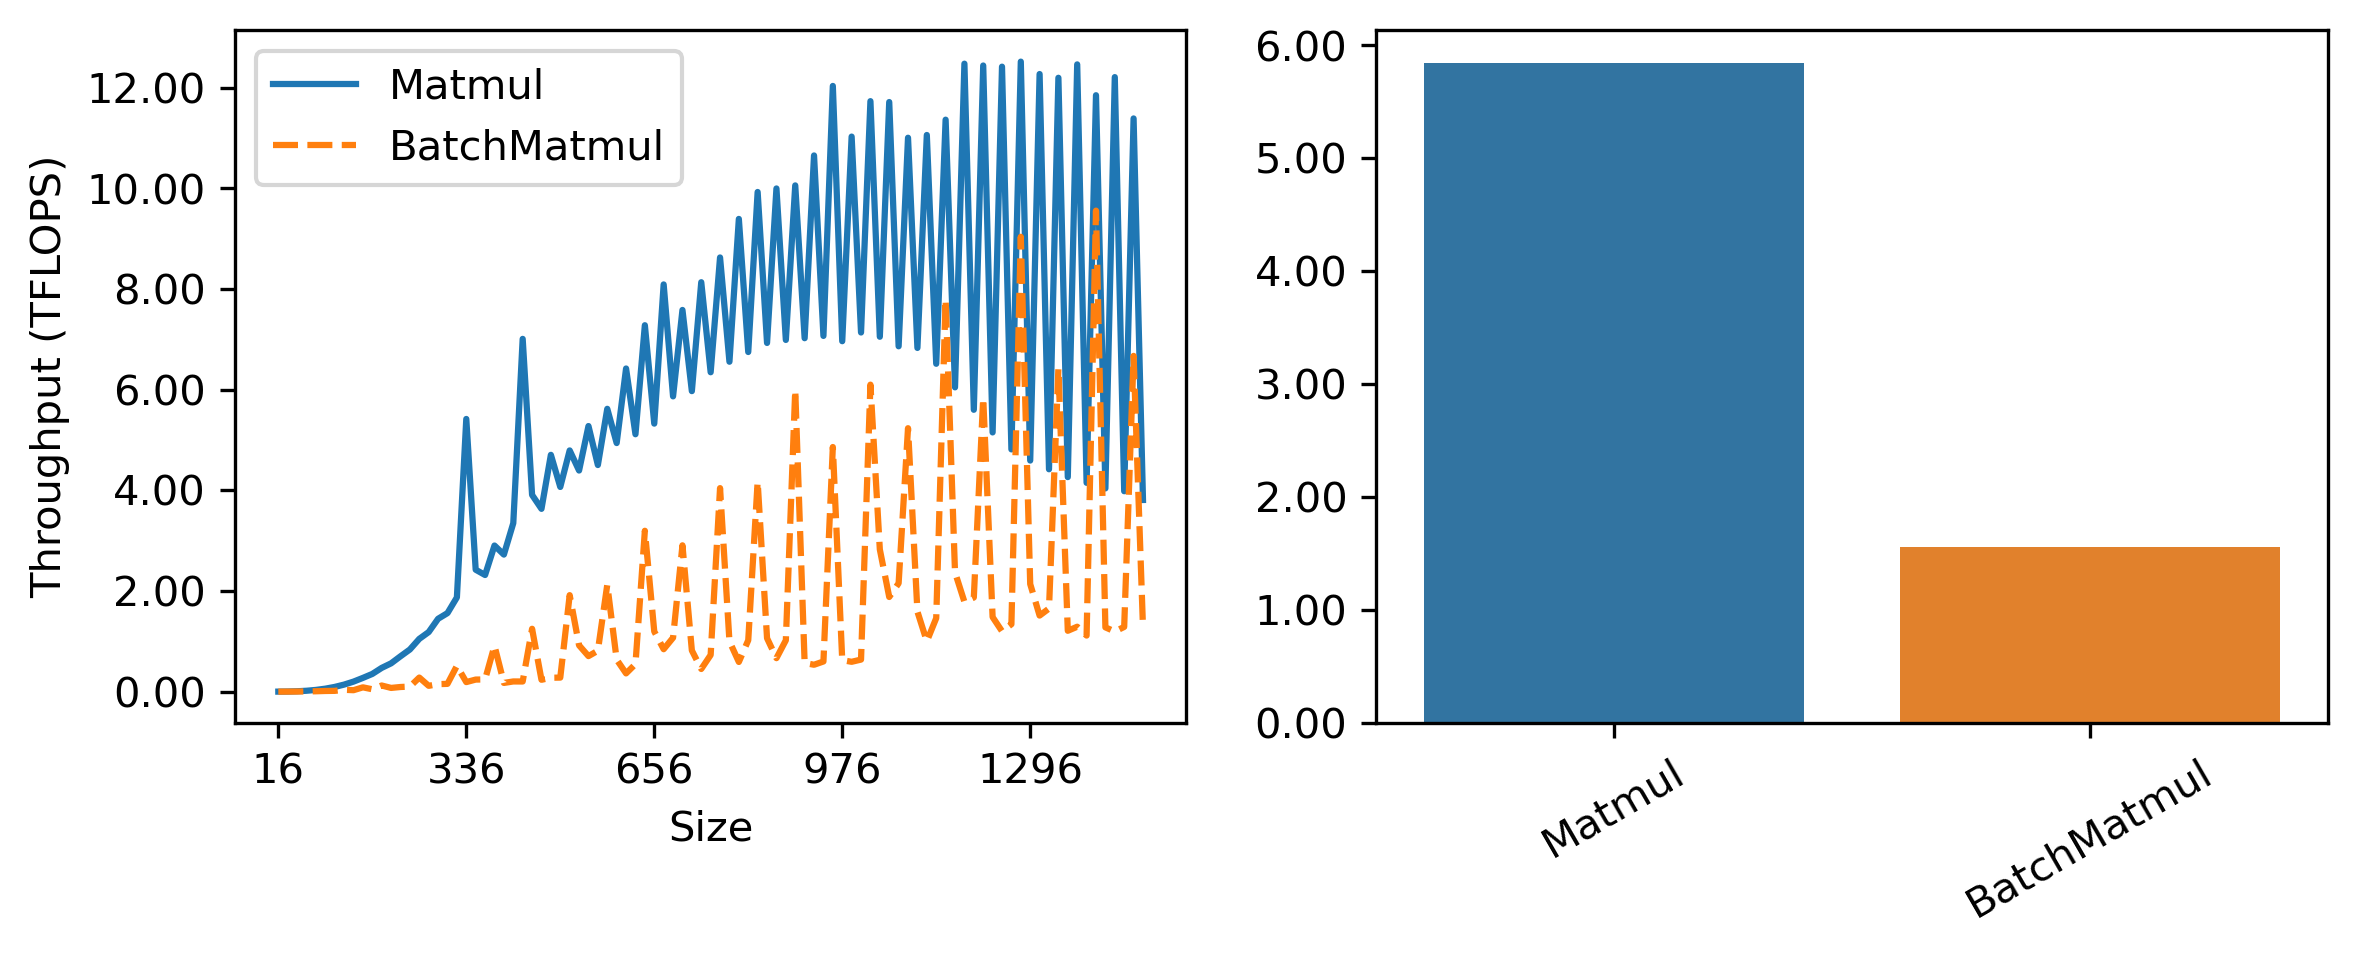

/tmp/ipykernel_1022345/778871182.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)


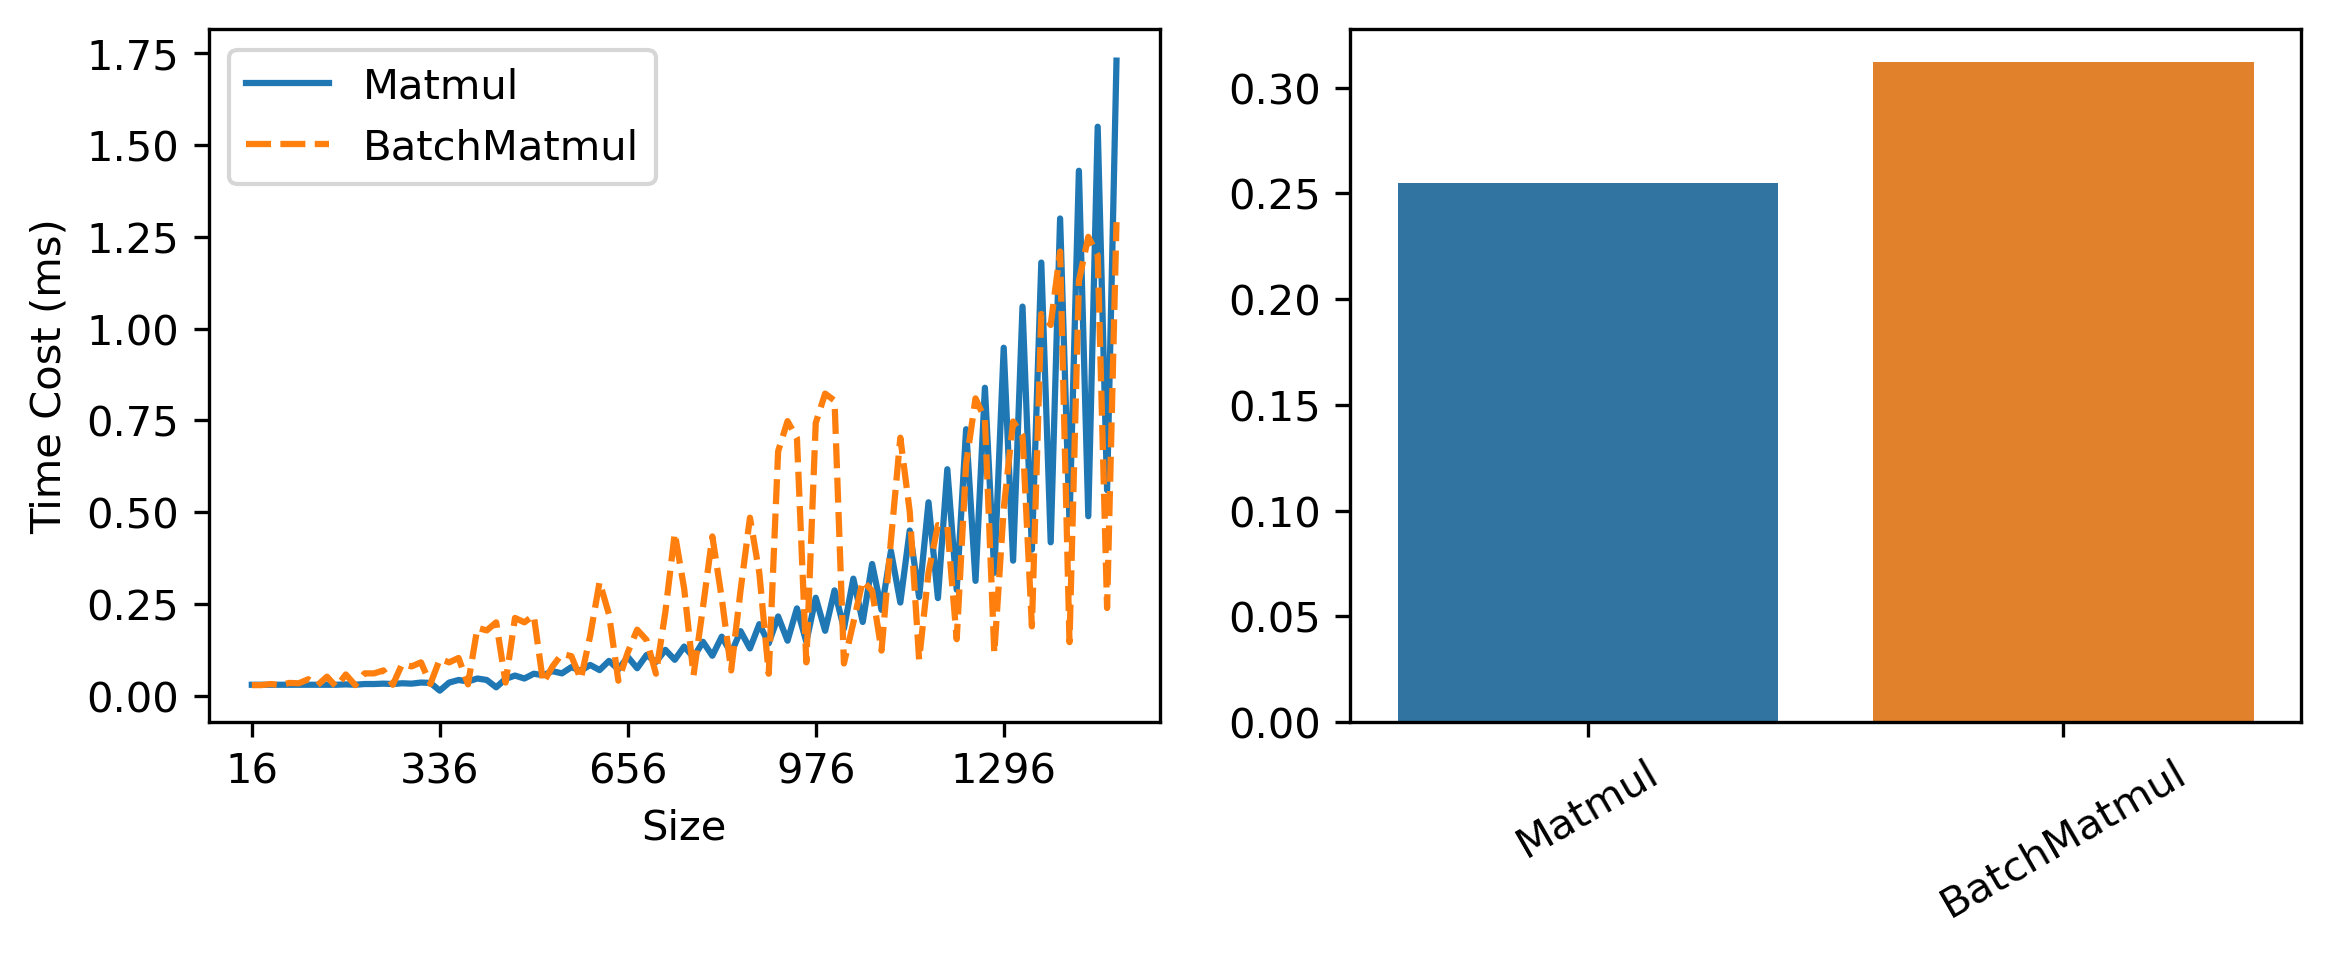

In [5]:
# do throughput
names = ['Matmul', 'BatchMatmul']
results = [mm_results, bmm_results]
throughputs = [mm_throughput, bmm_throughput]

from matplotlib.ticker import FuncFormatter
line_data = pd.DataFrame(dict(zip(names, [res for res in throughputs])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in throughputs])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Throughput (TFLOPS)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()

line_data = pd.DataFrame(dict(zip(names, [res for res in results])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in results])))
fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Time Cost (ms)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()